# AIOps Root Cause Analysis: Multi-Signal Correlation

This notebook demonstrates how observability signals such as metrics, logs, and traces can be analyzed together to identify likely root causes of performance issues and failures in a distributed application. Rather than examining each signal in isolation, the notebook brings them together into a unified diagnostic workflow.

In an AIOps setting, this approach helps move from simple detection to faster diagnosis. By correlating signals across multiple telemetry sources, teams can reduce investigation time, isolate failure patterns more effectively, and improve the speed and quality of operational response.


## Business Understanding

Modern distributed systems generate many observability signals, but identifying the true root cause of slowness or failures remains difficult because symptoms often appear across multiple services and telemetry sources at the same time. The business objective of this notebook is to correlate metrics, logs, and traces to identify likely causes of abnormal behavior more quickly and accurately. In an AIOps and observability context, this reduces troubleshooting effort, improves incident response, and helps convert raw telemetry into actionable diagnostic insight.


## Key Learning Insights

Key lessons emerged from building and interpreting the RCA workflow:

- **Multi-signal correlation is more powerful than single-signal analysis:** metrics show where behavior changed, logs add event context, and traces help localize the affected request path.
- **Temporal alignment matters:** the value of RCA improves significantly when spikes, errors, and trace anomalies are aligned in time.
- **Interpretability is critical:** visual summaries and decision logic make RCA output more actionable than isolated anomaly scores.
- **Operational value comes from narrowing the search space:** even when RCA does not prove causality, it can sharply reduce investigation time by surfacing the most likely contributing factors.


## Table of Contents

- [Business Understanding](#business-understanding)
- [Key Learning Insights](#key-learning-insights)
- [Data Understanding](#data-understanding)
- [Data Preparation](#data-preparation)
- [Modeling](#modeling)
    - [Baseline Dummy Classifier](#baseline-dummy-classifier)
    - [Decision Tree Classification](#decision-tree-classification)
- [Evaluation](#evaluation)
- [Results](#results)
- [Deployment and Operational Impact](#deployment-and-operational-impact)


In [5]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.patheffects as pe
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.dummy import DummyClassifier
from IPython.display import display
from IPython.core.display import Markdown

DATA_DIR = './data'
LC = {'normal': 'green', 'slow':'orange', 'error':'red'}

df = pd.read_csv(f'{DATA_DIR}/unified_features.csv')
df = df[df['label'].isin(['normal','slow','error'])].copy()

META  = ['trace_id','label','scenario','root_op','trace_structure_hash','minute','service']
FEATS = [c for c in df.columns if c not in META and pd.api.types.is_numeric_dtype(df[c])]
MET   = [c for c in FEATS if c.startswith('met_')]
SPAN  = [c for c in FEATS if not c.startswith('met_')]

# Composite scores (max of normalised constituents)
def _score(cols):
    ex = [c for c in cols if c in df.columns]
    if not ex: return pd.Series(0.0, index=df.index)
    return pd.DataFrame(MinMaxScaler().fit_transform(df[ex].fillna(0)),
                        index=df.index).max(axis=1)

df['score_remote'] = _score(['jd_dur_p95','jd_n1_pattern','jd_error_rate',
                              'met_db_pool_wait_ms','met_jdbc_avg_latency_ms'])
df['score_local']  = _score(['met_jvm_gc_pause_ms','met_jvm_heap_used_mb',
                              'met_cpu_usage_pct','met_memory_used_pct'])

nm = df[df['label']=='normal']
def p90(c): return nm[c].quantile(0.90) if c in nm.columns else 0
T = {c: p90(c) for c in ['score_remote','score_local','jd_n1_pattern',
                          'met_db_pool_wait_ms','met_jvm_gc_pause_ms',
                          'met_jvm_heap_used_mb','met_cpu_usage_pct',
                          'jd_error_rate','sp_error_rate','lg_error_ratio']}

print(df['label'].value_counts().to_string())


label
normal    2302
error     1272
slow      1090


## Data Understanding

This section explores the core observability patterns in the dataset using the classic RED signals: **Rate, Errors, and Duration**. These signals help reveal when abnormal behavior begins, how severe it becomes, and whether the issue appears to be load-driven, latency-driven, or error-driven.

From a diagnostic perspective, metrics are often the first place where abnormal system behavior becomes visible. They help establish the timing and severity of an incident, creating the foundation for deeper RCA using logs, traces, and interpretable models.


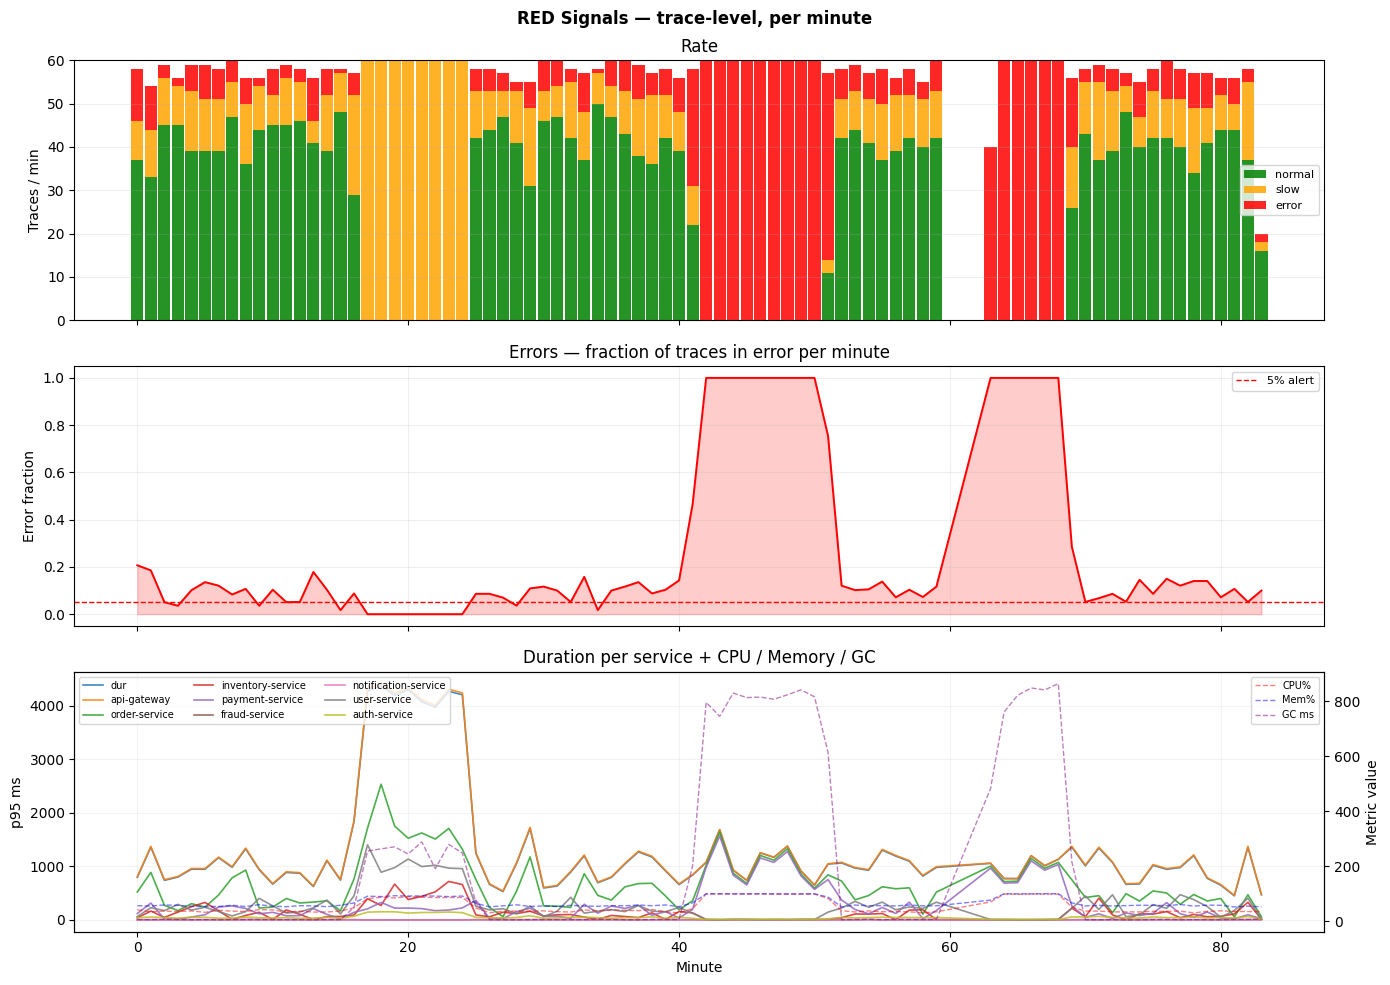

In [6]:
SC   = {'normal':'green', 'slow':'orange', 'error':'red'}
cmap = plt.colormaps['tab10']

# Per-minute trace-level aggregates
grp  = df.groupby(['minute','label'])
rate = grp['trace_id'].count().unstack('label').fillna(0)
errs = grp.apply(lambda g: (g['label']=='error').mean()).unstack('label').fillna(0)
SVC_P95 = {c.replace('sp_','').replace('_p95','').replace('_','-'): c
           for c in df.columns if c.startswith('sp_') and c.endswith('_p95')}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('RED Signals — trace-level, per minute', fontweight='bold')

# Rate
bottom = np.zeros(len(rate))
for lbl in ['normal','slow','error']:
    if lbl not in rate: continue
    axes[0].bar(rate.index, rate[lbl], bottom=bottom,
                color=SC[lbl], width=0.9, label=lbl, alpha=0.85)
    bottom += rate[lbl].values
axes[0].set_ylabel('Traces / min'); axes[0].set_title('Rate')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.2, axis='y')

# Errors: fraction of traces that are error, per minute
err_frac = df.groupby('minute').apply(lambda g: (g['label']=='error').mean())
axes[1].plot(err_frac.index, err_frac.values, color='red', lw=1.4)
axes[1].axhline(0.05, color='red', lw=1, ls='--', label='5% alert')
axes[1].fill_between(err_frac.index, err_frac.values, alpha=0.2, color='red')
axes[1].set_ylabel('Error fraction'); axes[1].set_title('Errors — fraction of traces in error per minute')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.2)

# Duration per service + CPU/Mem/GC
ax1 = axes[2]
for i, (svc, col) in enumerate(SVC_P95.items()):
    ts = df.groupby('minute')[col].mean()
    ax1.plot(ts.index, ts.values, lw=1.2, color=cmap(i), label=svc, alpha=0.85)
ax1.set_ylabel('p95 ms'); ax1.set_xlabel('Minute')
ax1.set_title('Duration per service + CPU / Memory / GC')
ax1.legend(fontsize=7, ncol=3, loc='upper left'); ax1.grid(alpha=0.15)

ax2 = ax1.twinx()
for mname, col, lbl in [('met_cpu_usage_pct','red','CPU%'),
                         ('met_memory_used_pct','blue','Mem%'),
                         ('met_jvm_gc_pause_ms','purple','GC ms')]:
    if mname in df.columns:
        s = df.groupby('minute')[mname].mean()
        ax2.plot(s.index, s.values, lw=1, ls='--', color=col, alpha=0.5, label=lbl)
ax2.set_ylabel('Metric value'); ax2.legend(fontsize=7, loc='upper right')

plt.tight_layout(); plt.show()


## Data Preparation

Before moving into diagnosis, the relevant observability features are aligned and organized into a consistent analytical view. This includes structuring the signal set so that metrics and derived features can be compared across normal, slow, and error scenarios.

This preparation step is important because effective RCA depends on meaningful correlation across signals. When the features are aligned correctly, downstream models and visualizations can more clearly highlight which patterns are associated with degraded behavior.


## Modeling

This notebook uses interpretable classification and rule-based reasoning to support root cause analysis rather than treating RCA as a black-box prediction problem. The emphasis is on surfacing patterns that help explain why a request appears normal, slow, or error-prone.

### Baseline Dummy Classifier

The baseline classifier provides a simple reference point for comparison and shows how much value is added by a more informative RCA model.

In [7]:
FEATS2 = FEATS + ['score_remote','score_local']
X = df[FEATS2].fillna(0)
y = df['label'].map({'normal':0,'slow':1,'error':2}).values
X_tr,X_te,y_tr,y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Instantiate and train a Dummy Classifier (e.g., 'most_frequent' strategy)
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_tr, y_tr)

# Evaluate the Dummy Classifier
print('Classification Report for Dummy Classifier (most_frequent):')
print(classification_report(y_te, dummy_clf.predict(X_te), target_names=['normal','slow','error']))

Classification Report for Dummy Classifier (most_frequent):
              precision    recall  f1-score   support

      normal       0.49      1.00      0.66       576
        slow       0.00      0.00      0.00       272
       error       0.00      0.00      0.00       318

    accuracy                           0.49      1166
   macro avg       0.16      0.33      0.22      1166
weighted avg       0.24      0.49      0.33      1166



### Decision Tree Classification

A decision tree is used because it is interpretable and can show which observability features contribute most strongly to separating normal, slow, and error conditions.


## Evaluation

The RCA workflow is evaluated based on how well it distinguishes normal, slow, and error scenarios, and how clearly it explains those distinctions. Interpretability matters as much as raw classification quality because the operational goal is to help humans diagnose issues quickly.

The decision tree and comparison views are useful here because they show not just whether the model works, but also which features and patterns are most strongly associated with abnormal behavior.


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       576
        slow       1.00      1.00      1.00       272
       error       1.00      1.00      1.00       318

    accuracy                           1.00      1166
   macro avg       1.00      1.00      1.00      1166
weighted avg       1.00      1.00      1.00      1166



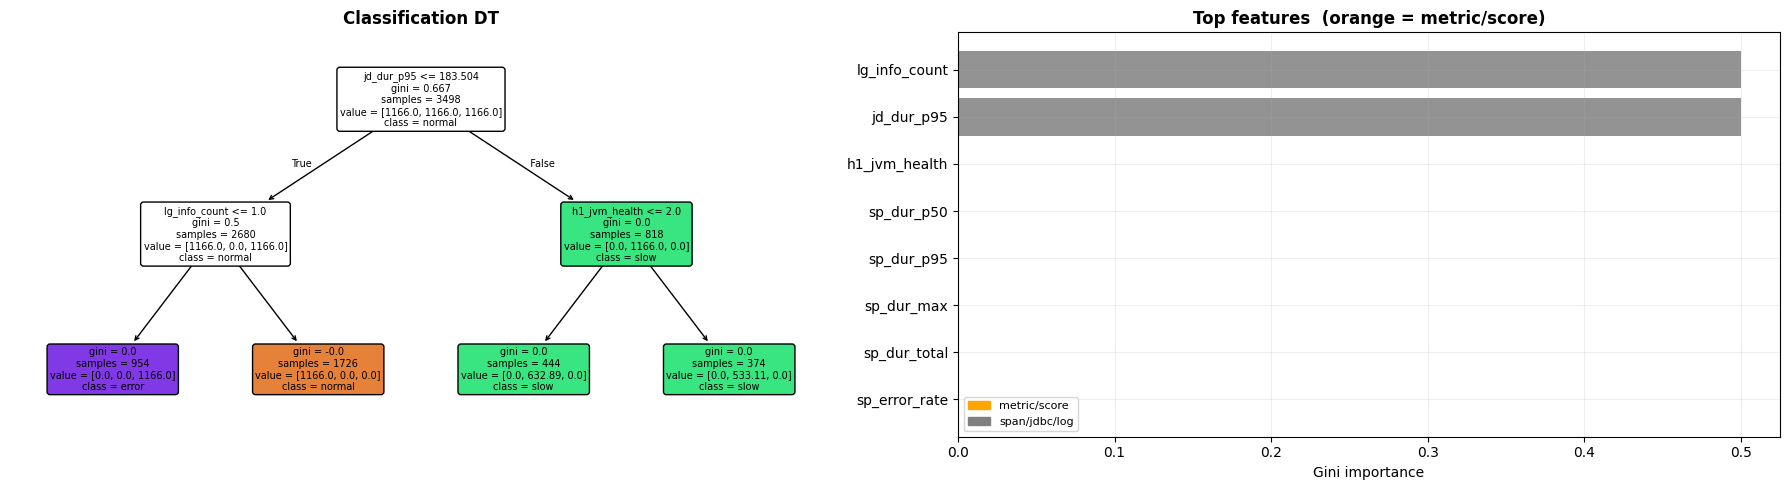

In [8]:
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42).fit(X_tr,y_tr)
print(classification_report(y_te, dt.predict(X_te), target_names=['normal','slow','error']))

fi = pd.Series(dt.feature_importances_, index=FEATS2).nlargest(8)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_tree(dt, feature_names=FEATS2, class_names=['normal','slow','error'],
          filled=True, rounded=True, fontsize=7, ax=axes[0], max_depth=3)
axes[0].set_title('Classification DT', fontweight='bold')

cols = ['orange' if f.startswith('met_') or 'score' in f else 'gray' for f in fi.index[::-1]]
axes[1].barh(fi.index[::-1], fi.values[::-1], color=cols, alpha=0.85)
axes[1].set_title('Top features  (orange = metric/score)', fontweight='bold')
axes[1].set_xlabel('Gini importance'); axes[1].grid(alpha=0.2)
axes[1].legend(handles=[mpatches.Patch(color='orange',label='metric/score'),
                         mpatches.Patch(color='gray',label='span/jdbc/log')], fontsize=8)
plt.tight_layout(); plt.show()


## Results

The RCA analysis shows that combining observability signals produces a more useful diagnostic view than relying on any one signal alone. Metrics establish when and how behavior changed, while the classifier helps identify which features are most associated with normal, slow, and error conditions.

Taken together, these views reduce ambiguity and narrow the set of likely contributing factors. Even when the workflow does not prove strict causality, it substantially improves diagnostic direction and reduces the time required to isolate the probable source of the issue.


## Deployment and Operational Impact

The rule-based troubleshooting tree represents how RCA output can be operationalized. In a real system, this kind of logic could be used to automatically correlate RED-signal anomalies with suspicious feature patterns and then guide operators toward the most likely next diagnostic step.

From an AIOps perspective, the value is operational leverage: faster incident triage, shorter mean time to resolution (MTTR), less manual searching across dashboards and logs, and more consistent identification of recurring failure patterns.


## Observability Actionability

This notebook demonstrates how multi-signal telemetry can be turned into a practical RCA workflow. Instead of treating observability data as separate dashboards, the analysis combines metrics and interpretable models to support faster diagnosis and clearer operational decision-making.

Overall, this approach helps teams move from simply detecting that something is wrong to identifying where to investigate first and which factors are most likely contributing to the issue.
